Pretrained Models and Transfer Learning Project:  
Benjamin Kwon: 009241284

Python:  
v3.12.0

Dataset:  
CIFAR-10

Tech:  
Pytorch

Pretrained Model:  
EfficientNet-B0


In [1]:
# Import PyTorch and Detect GPU for hardware acceleration
import torch
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [2]:
# Extract weights and preprocessing from EfficientNet-B0
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights

weights = EfficientNet_B0_Weights.DEFAULT

preprocess = weights.transforms()
print(preprocess)

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)


In [3]:
# Load CIFAR-10 using EfficientNet-B0 preprocessing values with Data Augmentation
# Split the training set into train_subset and val_subset using indices

from torchvision import transforms
from torch.utils.data import Subset
import numpy as np

# Set transform values with respect to the pretrained model's weight and preprocessing values
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224, interpolation=transforms.InterpolationMode.BICUBIC),# Data Augmentation: differing resize and crop
    transforms.RandomHorizontalFlip(),# Data Augmentation: Horizontal Flips
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

eval_transform = transforms.Compose([
    transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Load the CIFAR-10 with the transform composition
full_train_dataset_train_tf = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=train_transform
)

full_train_dataset_eval_tf = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=eval_transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=eval_transform
)

num_train = len(full_train_dataset_train_tf)
indices = np.random.RandomState(seed=42).permutation(num_train)

train_size = int(0.9 * num_train)
train_indices = indices[:train_size]
val_indices = indices[train_size:]

train_subset = Subset(full_train_dataset_train_tf, train_indices)
val_subset = Subset(full_train_dataset_eval_tf, val_indices)

print("Train subset size:", len(train_subset))
print("Validation subset size:", len(val_subset))
print("Test dataset size:", len(test_dataset))

train_image, train_label = train_subset[0]
val_image, val_label = val_subset[0]
test_image, test_label = test_dataset[0]

print("Train image shape:", train_image.shape, "| label:", train_label)
print("Val image shape:", val_image.shape, "| label:", val_label)
print("Test image shape:", test_image.shape, "| label:", test_label)

Train subset size: 45000
Validation subset size: 5000
Test dataset size: 10000
Train image shape: torch.Size([3, 224, 224]) | label: 7
Val image shape: torch.Size([3, 224, 224]) | label: 3
Test image shape: torch.Size([3, 224, 224]) | label: 3


In [4]:
# DataLoader
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0
)

images, labels = next(iter(train_loader))

print("Batch image shape:", images.shape)
print("Batch label shape:", labels.shape)
print("First 5 labels:", labels[:5])

Batch image shape: torch.Size([64, 3, 224, 224])
Batch label shape: torch.Size([64])
First 5 labels: tensor([2, 8, 4, 7, 5])


In [5]:
# Load the Pretrained Model

model = efficientnet_b0(weights=weights)

print(model)
print(model.classifier)

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [6]:
# Replace the classifier from 1000 to 10 class

import torch.nn as nn

model.classifier[1] = nn.Linear(in_features=1280, out_features=10)
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=10, bias=True)
)


In [7]:
# Freeze the backbone: all parameters

for param in model.parameters():
    param.requires_grad = False

# Unfreeze the classifier head for initial training
for param in model.classifier.parameters():
    param.requires_grad = True

# Print what is trainable and what isn't
trainable_params = []
frozen_params = []

for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)
    else:
        frozen_params.append(name)

print("Trainable parameters:")
for name in trainable_params:
    print(" ", name)

print("\nNumber of trainable parameter tensors:", len(trainable_params))
print("Number of frozen parameter tensors:", len(frozen_params))

# Full List:
print('\nFull List: ')
for name, param in model.named_parameters():
    status = "trainable" if param.requires_grad else "frozen"
    print(f"{name:50s} {str(tuple(param.shape)):20s} {status}")

Trainable parameters:
  classifier.1.weight
  classifier.1.bias

Number of trainable parameter tensors: 2
Number of frozen parameter tensors: 211

Full List: 
features.0.0.weight                                (32, 3, 3, 3)        frozen
features.0.1.weight                                (32,)                frozen
features.0.1.bias                                  (32,)                frozen
features.1.0.block.0.0.weight                      (32, 1, 3, 3)        frozen
features.1.0.block.0.1.weight                      (32,)                frozen
features.1.0.block.0.1.bias                        (32,)                frozen
features.1.0.block.1.fc1.weight                    (8, 32, 1, 1)        frozen
features.1.0.block.1.fc1.bias                      (8,)                 frozen
features.1.0.block.1.fc2.weight                    (32, 8, 1, 1)        frozen
features.1.0.block.1.fc2.bias                      (32,)                frozen
features.1.0.block.2.0.weight                      

In [8]:
# Move the model to the device
model = model.to(device) # RTX 3080 TI

# Define the loss function
criterion = nn.CrossEntropyLoss()

# Define the optimizer
import torch.optim as optim

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()), # Filter out frozen parameters; Train only the classifier head in this case
    lr = 1e-3 # Learning Rate
)

num_trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
num_total = sum(p.numel() for p in model.parameters())

print("Trainable parameters:", num_trainable)
print("Total parameters:", num_total)

Trainable parameters: 12810
Total parameters: 4020358


In [9]:
# Training and Validation Loop
import time

def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = outputs.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

def validate_one_epoch(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

# Epoch training and evaluation
num_epochs = 10

# Train the classifier-head
train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    epoch_duration = time.time() - epoch_start

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        f"| Time: {epoch_duration:.2f} sec"
    )

total_duration = time.time() - start_time
print(f"\nTotal training + validation time: {total_duration:.2f} sec")
print(f"Total time in minutes: {total_duration / 60:.2f} min")

Epoch [1/10] Train Loss: 1.3385 | Train Acc: 0.5521 | Val Loss: 0.7029 | Val Acc: 0.7842| Time: 41.49 sec
Epoch [2/10] Train Loss: 1.1647 | Train Acc: 0.5963 | Val Loss: 0.6567 | Val Acc: 0.7906| Time: 41.92 sec
Epoch [3/10] Train Loss: 1.1416 | Train Acc: 0.6042 | Val Loss: 0.6380 | Val Acc: 0.7898| Time: 40.83 sec
Epoch [4/10] Train Loss: 1.1374 | Train Acc: 0.6061 | Val Loss: 0.6426 | Val Acc: 0.7854| Time: 40.76 sec
Epoch [5/10] Train Loss: 1.1422 | Train Acc: 0.6046 | Val Loss: 0.6243 | Val Acc: 0.7958| Time: 40.72 sec
Epoch [6/10] Train Loss: 1.1308 | Train Acc: 0.6089 | Val Loss: 0.6228 | Val Acc: 0.7906| Time: 41.08 sec
Epoch [7/10] Train Loss: 1.1268 | Train Acc: 0.6080 | Val Loss: 0.6152 | Val Acc: 0.7938| Time: 41.79 sec
Epoch [8/10] Train Loss: 1.1313 | Train Acc: 0.6097 | Val Loss: 0.6068 | Val Acc: 0.8008| Time: 41.50 sec
Epoch [9/10] Train Loss: 1.1295 | Train Acc: 0.6071 | Val Loss: 0.6072 | Val Acc: 0.8000| Time: 41.98 sec
Epoch [10/10] Train Loss: 1.1246 | Train Acc: 

# Analysis on Phase 1: initial classifier-only transfer-learning phase

In Phase 1, the pretrained EfficientNet-B0 backbone was frozen while only the new classifier head was trained for 10 epochs. The model improved rapidly during the first few epochs, with validation accuracy increasing from 78.42% in epoch 1 to values near 80% after. The best validation accuracy reached 80.08% at epoch 8.

Training loss decreased from 1.3385 to 1.1246, while validation loss decreased from 0.7029 to 0.6063. Training accuracy improved from 55.21% to 61.08%, showing that the classifier had successfully adapted to the pretrained EfficientNet-B0 features. After the improvements in the beginning, the validation metrics fluctuated within a narrow range, indicating that the classifier-only setup had largely converged.

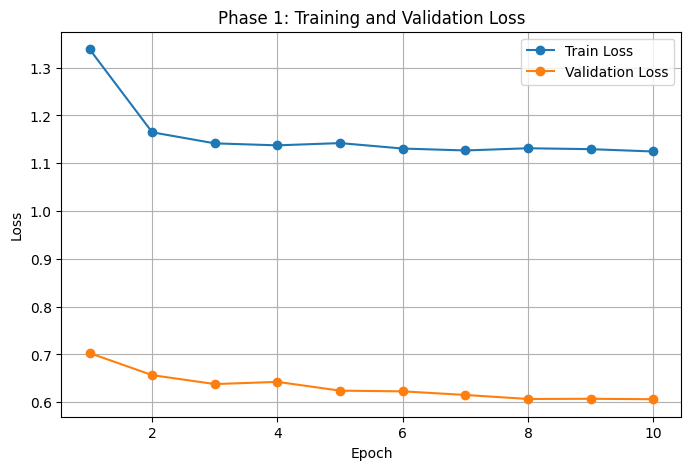

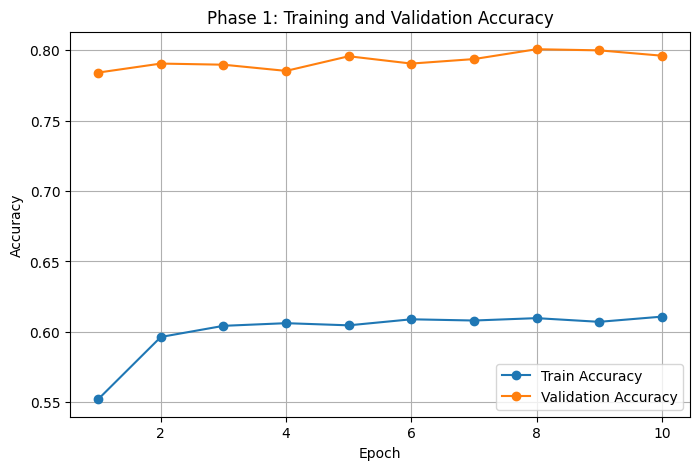

In [18]:
# Plot our results from the Initial Classifier-only Transfer-learning Phase

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, marker='o', label='Train Loss')
plt.plot(epochs, val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Phase 1: Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Phase 1: Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [11]:
# Save the model from Phase 1
torch.save(model.state_dict(), "phase1.pth")

In [12]:
# Phase 2: Unfreeze the last 2 features for fine-tuning and set new learning rate of 1e-4

for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

for layer in model.features[-2:]:
    for param in layer.parameters():
        param.requires_grad = True

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

trainable_params = []
for name, param in model.named_parameters():
    if param.requires_grad:
        trainable_params.append(name)

print("Trainable parameters:")
for name in trainable_params:
    print(name)

Trainable parameters:
features.7.0.block.0.0.weight
features.7.0.block.0.1.weight
features.7.0.block.0.1.bias
features.7.0.block.1.0.weight
features.7.0.block.1.1.weight
features.7.0.block.1.1.bias
features.7.0.block.2.fc1.weight
features.7.0.block.2.fc1.bias
features.7.0.block.2.fc2.weight
features.7.0.block.2.fc2.bias
features.7.0.block.3.0.weight
features.7.0.block.3.1.weight
features.7.0.block.3.1.bias
features.8.0.weight
features.8.1.weight
features.8.1.bias
classifier.1.weight
classifier.1.bias


In [13]:
# Fine-tune 1: Train the last two features and the classifier head

num_epochs = 25 # Increase epoch because previous experiment of 5, 10, 15 epochs did not converge

ft1_train_losses = []
ft1_train_accuracies = []
ft1_val_losses = []
ft1_val_accuracies = []

start_time = time.time()

for epoch in range(num_epochs):
    epoch_start = time.time()
    
    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    if device.type == "cuda":
        torch.cuda.synchronize()

    epoch_duration = time.time() - epoch_start

    ft1_train_losses.append(train_loss)
    ft1_train_accuracies.append(train_acc)
    ft1_val_losses.append(val_loss)
    ft1_val_accuracies.append(val_acc)

    print(
        f"Epoch [{epoch+1}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} "
        f"| Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}"
        f"| Time: {epoch_duration:.2f} sec"
    )

total_duration = time.time() - start_time
print(f"\nTotal training + validation time: {total_duration:.2f} sec")
print(f"Total time in minutes: {total_duration / 60:.2f} min")

Epoch [1/25] Train Loss: 1.0058 | Train Acc: 0.6483 | Val Loss: 0.4569 | Val Acc: 0.8428| Time: 42.36 sec
Epoch [2/25] Train Loss: 0.9081 | Train Acc: 0.6826 | Val Loss: 0.4138 | Val Acc: 0.8520| Time: 43.78 sec
Epoch [3/25] Train Loss: 0.8517 | Train Acc: 0.6992 | Val Loss: 0.3807 | Val Acc: 0.8666| Time: 43.20 sec
Epoch [4/25] Train Loss: 0.8129 | Train Acc: 0.7176 | Val Loss: 0.3675 | Val Acc: 0.8694| Time: 43.09 sec
Epoch [5/25] Train Loss: 0.7919 | Train Acc: 0.7249 | Val Loss: 0.3412 | Val Acc: 0.8820| Time: 42.60 sec
Epoch [6/25] Train Loss: 0.7652 | Train Acc: 0.7322 | Val Loss: 0.3462 | Val Acc: 0.8778| Time: 42.00 sec
Epoch [7/25] Train Loss: 0.7470 | Train Acc: 0.7364 | Val Loss: 0.3195 | Val Acc: 0.8870| Time: 41.89 sec
Epoch [8/25] Train Loss: 0.7289 | Train Acc: 0.7430 | Val Loss: 0.3118 | Val Acc: 0.8910| Time: 41.86 sec
Epoch [9/25] Train Loss: 0.7161 | Train Acc: 0.7484 | Val Loss: 0.3080 | Val Acc: 0.8924| Time: 41.69 sec
Epoch [10/25] Train Loss: 0.7001 | Train Acc: 

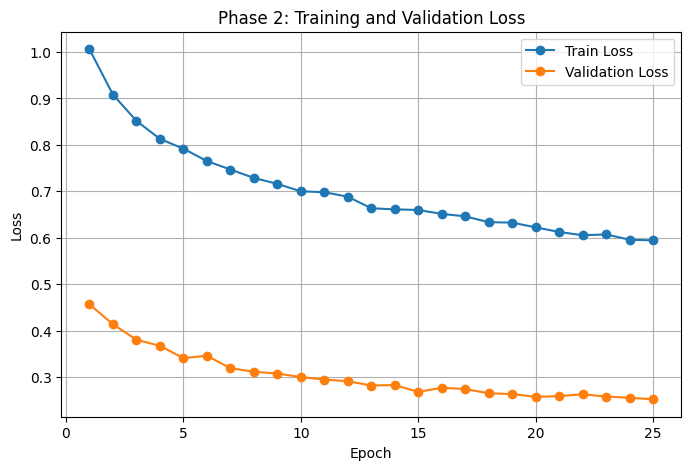

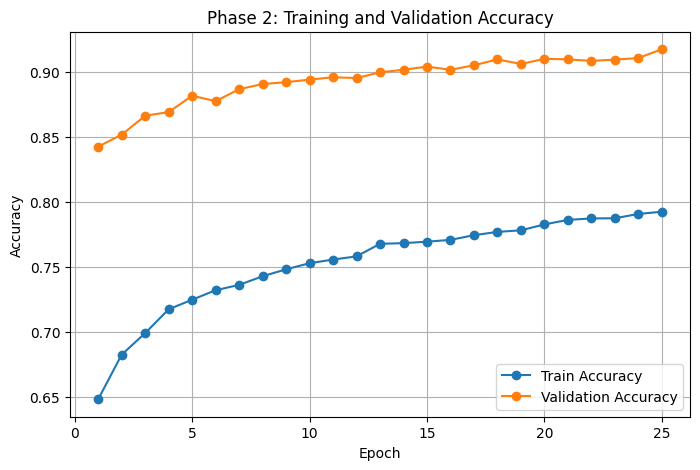

In [19]:
# Plot our results for Fine-Tune 1: Last 2 features and a classifier head

epochs = range(1, len(ft1_train_losses) + 1)

plt.figure(figsize=(8, 5))
plt.plot(epochs, ft1_train_losses, marker='o', label='Train Loss')
plt.plot(epochs, ft1_val_losses, marker='o', label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Phase 2: Training and Validation Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(epochs, ft1_train_accuracies, marker='o', label='Train Accuracy')
plt.plot(epochs, ft1_val_accuracies, marker='o', label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Phase 2: Training and Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [15]:
# Save the model from Phase 2
torch.save(model.state_dict(), "phase2.pth")

# Analysis on Phase 2: Fine-Tune 1: Train Last 2 Features and the Classifier Head

In Phase 2, the last two feature stages of the EfficientNet-B0 backbone were unfrozen and fine-tuned together with the classifier head using a smaller learning rate of 1e-4. This produced a substantial improvement over the classifier-only setup from Phase 1.

Training loss decreased from 1.0058 to 0.5945, while validation loss decreased from 0.4569 to 0.2527 over 25 epochs. Training accuracy improved from 64.83% to 79.27%, and validation accuracy increased from 84.28% to 91.78%.

These results show that partial backbone fine-tuning allowed the later pretrained features and classifier head to adapt together more effectively to the CIFAR-10 task. Compared to Phase 1, which converged within the later epochs of the 10-epoch run, Phase 2 continued to improve throughout the 25-epoch training window. This suggests that fine-tuning the later backbone layers provided a deeper and more gradual adaptation process than classifier-only training.

Training remained computationally efficient, requiring approximately 42.3 seconds per epoch and about 17.65 minutes total for 25 epochs. Overall, Phase 2 demonstrates that controlled fine-tuning of the later backbone layers can significantly improve generalization performance while maintaining a relatively low computational cost.

In [16]:
# Test Evaluation

def evaluate_on_test(model, loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = outputs.max(1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    test_loss = running_loss / total
    test_acc = correct / total

    return test_loss, test_acc

test_loss, test_acc = evaluate_on_test(model, test_loader, criterion, device)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test Accuracy (%): {test_acc * 100:.2f}%")

Test Loss: 0.2593
Test Accuracy: 0.9110
Test Accuracy (%): 91.10%


# Test Evaluation Report

The final Phase 2 model was evaluated on the CIFAR-10 test set to measure its generalization performance on unseen data. The model achieved a test loss of 0.2593 and a test accuracy of 91.10%.

This result is close to the best validation accuracy of 91.78%, which suggests that the model generalized well and did not heavily overfit to the validation set. The small gap between validation and test performance indicates that the improvements observed during fine-tuning were not limited to the validation split and transfered effectively to unseen test images.

# Final Report
## Pretrained Models and Transfer Learning for CIFAR-10 Image Classification Using EfficientNet-B0 ##

### Dataset: CIFAR-10
The dataset used in this project was CIFAR-10, which contains 60,000 color images of size 32x32 across 10 classes.
- airplane, automobile, bird, cat, deer, dog, frog, horse, ship, truck

The dataset is divided into
- 50,000 training images
- 10,000 test images

Because the project required a validation set, the original training set was split into
  - 45,000 training images
  - 5,000 validation images

This allowed us a set of training, validation, and test data.

### Neural Network Architecture: EfficientNet-B0
The pretrained model used for this project was EfficientNet-B0. EfficientNet-B0 is a CNN designed to achieve strong performance with relatively low computational cost. The model was pretrained on ImageNet and contains visual feature extractors.
#### Architecture Overview
The network consists of
- Convolutional feature extraction backbone
- Multiple EfficientNet blocks for hierarchical feature learning
- A classifier head at the end

The original pretrained classifier head was:
- Dropout(p=0.2)
- Linear(1280, 1000)

Because CIFAR-10 has only 10 classes, the final classifier layer was replaced with:
- Dropout(p=0.2)
- Linear(1280,10)

Input and Output
- Input: RGB Image
- Original CIFAR-10 size: 32 x 32 x 3
- Model input after preprocessing: 224 x 224 x 3
- Output: 10 class scores corresponding to the CIFAR-10 classes

### Input Pipeline, Preprocessing, and Data Augmentation
Because EfficientNet-B0 was pretrained on ImageNet, the CIFAR-10 images had to be adapted to match the pretrained model's expected input format.

#### Training Transform
The training pipeline used
- RandomResizedCrop(224)
- RandomHorizontalFlip()
- ToTensor()
- Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

This transform added augmentation only to the training data. The purpose of augmentation was to improve generalization by exposing the model to slightly different versions of the same original image.

#### Validation and Test Transform
The validation and test pipeline used:
- Resize(256)
- CenterCrop(224)
- ToTensor()
- Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

Unlike training, validation and test data were not augmented. This is to ensure that evaluation remained stable and consistent.

#### Data Loader
PyTorch DataLoader was used to batch and shuffle the data:
- Batch size: 64
- Training Loader: shuffled
- Validation and Test Loaders: not shuffled

### Design and Modification Scheme
Several design modifications were made to adapt the pretrained model to CIFAR-10

#### Replaced the classifier head
The original EfficientNet-B0 was designed for 1000 ImageNet classes. To make the model compatible with CIFAR-10, the final linear layer was replaced with a new layer that outputs 10 classes.

#### Adapted CIFAR-10 to the pretrained model
CIFAR-10 images are only 32 x 32, which is much smaller than the input size expected by EfficientNet-B0. Thus, the images were resized and cropped according to the preprocessing associated with the model's pretrained weights.

#### Added Training-only Augmentation
Random cropping and horizontal flipping were used only on the training set. This made the training images more diverse and helped the model generalize better.

#### Two-stage Transfer Learning Strategy
The training process was divided into two phases:

Phase 1: Classifier-only Training
- EfficientNet-B0 backbone was frozen
- Only the new classifier head was trained
- Learning Rate: 1e-3

This allowed the new classifier to learn how to interpret the pretrained ImageNet features without changing the backbone.

Phase 2: Partial Fine-Tuning
- The last two feature stages of the EfficientNet-B0 were unfrozen
- The classifier head remained trainable
- Learning rate was reduced to 1e-4

This allowed the classifier head and end backbone features to adapt together to better fit CIFAR-10

#### Training Configuration
The model was trained using:
- optimizer: Adam
- loss function: CrossEntropyLoss

These were selected because they are standard and effective choices for multi-class image classification.

### Hyperparameters
| Component | Value|
| :-: | :-:|
|Model | EfficientNet-B0 pretrained on ImageNet|
|Dataset | CIFAR-10|
|Train/Validation Split| 90%/10% of original training set|
|Batch size| 64|
|Phase 1 Learning Rate | 1e-3|
|Phase 2 Learning Rate | 1e-4|
|Optimizer | Adam|
|Loss Function | CrossEntropyLoss|
|Phase 1 Epochs | 10|
|Phase 2 Epochs | 25|
|Training Augmentation | RandomResizedCrop(224), RandomHorizontalFlip()|
|Validation/Test Preprocessing | Resize(256), CenterCrop(224), Normalize(ImageNet mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])|

### Results
#### Phase 1: Classifier-only Transfer Learning
In the initial transfer-learning phase, only the new classifier head was trained while the pretrained EfficientNet-B0 backbone remained frozen.

Results:
- Training Loss decreased steadily and converged at approximately 1.125
- Validation Loss decreased and converged at approximately 0.606
- Training accuracy increased and converged at approximately 61%
- Validation accuracy reached approximately 80%

The model demonstrated fast convergence, with most improvements occurring within the first 3-4 epochs. After this point, both loss and accuracy converged, indicating that the classifier-only configuration had reached its performance limit.

Training required approximately 41 seconds per epoch, totaling about 6.89 minutes for 10 epochs.

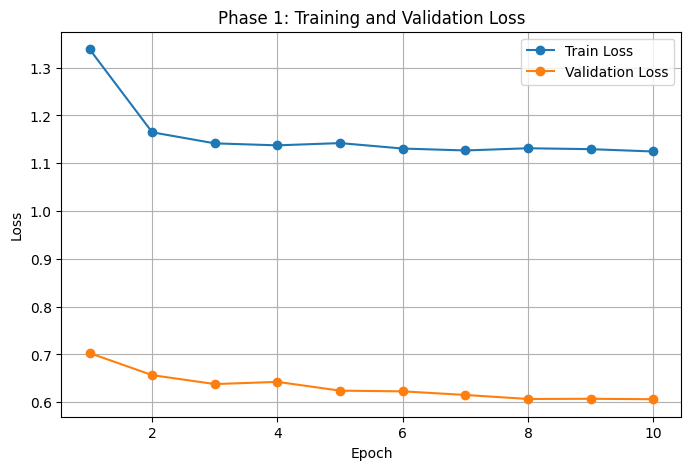

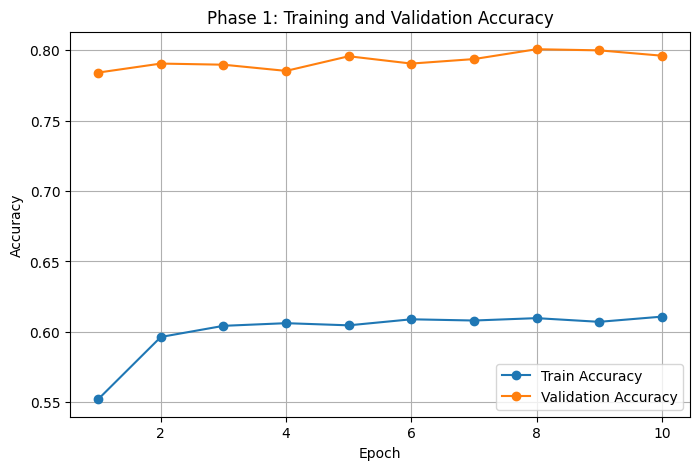

In [18]:
# Copy and Pasted the results from Phase 1
# The Report continues down
Epoch [1/10] Train Loss: 1.3385 | Train Acc: 0.5521 | Val Loss: 0.7029 | Val Acc: 0.7842| Time: 41.49 sec
Epoch [2/10] Train Loss: 1.1647 | Train Acc: 0.5963 | Val Loss: 0.6567 | Val Acc: 0.7906| Time: 41.92 sec
Epoch [3/10] Train Loss: 1.1416 | Train Acc: 0.6042 | Val Loss: 0.6380 | Val Acc: 0.7898| Time: 40.83 sec
Epoch [4/10] Train Loss: 1.1374 | Train Acc: 0.6061 | Val Loss: 0.6426 | Val Acc: 0.7854| Time: 40.76 sec
Epoch [5/10] Train Loss: 1.1422 | Train Acc: 0.6046 | Val Loss: 0.6243 | Val Acc: 0.7958| Time: 40.72 sec
Epoch [6/10] Train Loss: 1.1308 | Train Acc: 0.6089 | Val Loss: 0.6228 | Val Acc: 0.7906| Time: 41.08 sec
Epoch [7/10] Train Loss: 1.1268 | Train Acc: 0.6080 | Val Loss: 0.6152 | Val Acc: 0.7938| Time: 41.79 sec
Epoch [8/10] Train Loss: 1.1313 | Train Acc: 0.6097 | Val Loss: 0.6068 | Val Acc: 0.8008| Time: 41.50 sec
Epoch [9/10] Train Loss: 1.1295 | Train Acc: 0.6071 | Val Loss: 0.6072 | Val Acc: 0.8000| Time: 41.98 sec
Epoch [10/10] Train Loss: 1.1246 | Train Acc: 0.6108 | Val Loss: 0.6063 | Val Acc: 0.7962| Time: 41.62 sec

#### Phase 2: Fine-tuning the last two feature stages
After the classifier-only phase, the last two feature stages of the EfficientNet-B0 backbone were unfrozen and fine-tuned using a smaller learning rate of 1e-4.
- Training loss decreased from 1.0058 to 0.5946
- Validation loss decreased from 0.4569 to 0.2527
- Training accuracy improved from 64.83% to 79.27%
- Validation accuracy increased from 84.28% to 91.78%

Fine-tuning resulted significant performance improvement compared to Phase 1. The model continued to show stable convergence, with validation metrics improving steadily across epochs.

Training time remained consistent at around 43 seconds per epoch, showing that partial fine-tuning added minimal computational overhead.

These results indicate that allowing the classifier head and later backbone layers to adapt together enables the model to better specialize to the CIFAR-10 dataset.

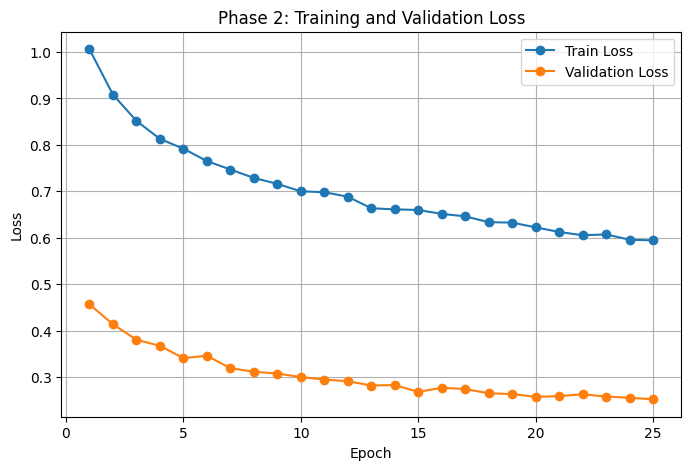

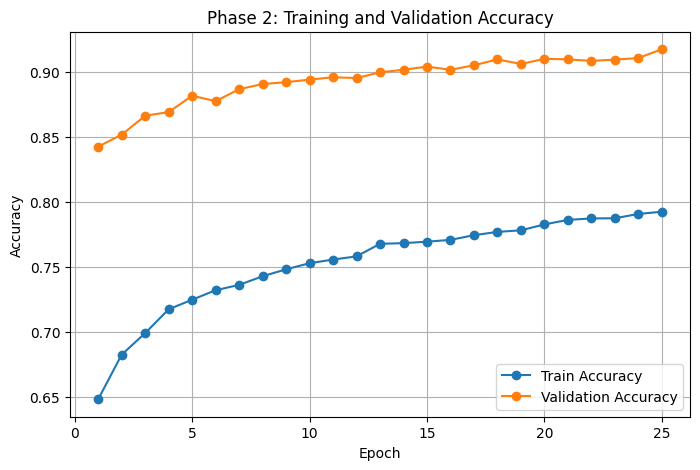

In [19]:
# Matplot from Phase 2:
# The Report continues down
Epoch [1/25] Train Loss: 1.0058 | Train Acc: 0.6483 | Val Loss: 0.4569 | Val Acc: 0.8428| Time: 42.36 sec
Epoch [2/25] Train Loss: 0.9081 | Train Acc: 0.6826 | Val Loss: 0.4138 | Val Acc: 0.8520| Time: 43.78 sec
Epoch [3/25] Train Loss: 0.8517 | Train Acc: 0.6992 | Val Loss: 0.3807 | Val Acc: 0.8666| Time: 43.20 sec
Epoch [4/25] Train Loss: 0.8129 | Train Acc: 0.7176 | Val Loss: 0.3675 | Val Acc: 0.8694| Time: 43.09 sec
Epoch [5/25] Train Loss: 0.7919 | Train Acc: 0.7249 | Val Loss: 0.3412 | Val Acc: 0.8820| Time: 42.60 sec
Epoch [6/25] Train Loss: 0.7652 | Train Acc: 0.7322 | Val Loss: 0.3462 | Val Acc: 0.8778| Time: 42.00 sec
Epoch [7/25] Train Loss: 0.7470 | Train Acc: 0.7364 | Val Loss: 0.3195 | Val Acc: 0.8870| Time: 41.89 sec
Epoch [8/25] Train Loss: 0.7289 | Train Acc: 0.7430 | Val Loss: 0.3118 | Val Acc: 0.8910| Time: 41.86 sec
Epoch [9/25] Train Loss: 0.7161 | Train Acc: 0.7484 | Val Loss: 0.3080 | Val Acc: 0.8924| Time: 41.69 sec
Epoch [10/25] Train Loss: 0.7001 | Train Acc: 0.7530 | Val Loss: 0.3004 | Val Acc: 0.8944| Time: 41.81 sec
Epoch [11/25] Train Loss: 0.6982 | Train Acc: 0.7559 | Val Loss: 0.2949 | Val Acc: 0.8962| Time: 41.80 sec
Epoch [12/25] Train Loss: 0.6884 | Train Acc: 0.7583 | Val Loss: 0.2915 | Val Acc: 0.8956| Time: 41.89 sec
Epoch [13/25] Train Loss: 0.6637 | Train Acc: 0.7680 | Val Loss: 0.2821 | Val Acc: 0.9000| Time: 41.81 sec
Epoch [14/25] Train Loss: 0.6612 | Train Acc: 0.7685 | Val Loss: 0.2832 | Val Acc: 0.9020| Time: 41.70 sec
Epoch [15/25] Train Loss: 0.6599 | Train Acc: 0.7696 | Val Loss: 0.2685 | Val Acc: 0.9044| Time: 41.65 sec
Epoch [16/25] Train Loss: 0.6515 | Train Acc: 0.7710 | Val Loss: 0.2773 | Val Acc: 0.9020| Time: 41.64 sec
Epoch [17/25] Train Loss: 0.6462 | Train Acc: 0.7746 | Val Loss: 0.2746 | Val Acc: 0.9054| Time: 42.47 sec
Epoch [18/25] Train Loss: 0.6336 | Train Acc: 0.7772 | Val Loss: 0.2655 | Val Acc: 0.9100| Time: 43.73 sec
Epoch [19/25] Train Loss: 0.6327 | Train Acc: 0.7784 | Val Loss: 0.2638 | Val Acc: 0.9064| Time: 42.57 sec
Epoch [20/25] Train Loss: 0.6225 | Train Acc: 0.7829 | Val Loss: 0.2579 | Val Acc: 0.9104| Time: 41.61 sec
Epoch [21/25] Train Loss: 0.6126 | Train Acc: 0.7864 | Val Loss: 0.2593 | Val Acc: 0.9100| Time: 43.40 sec
Epoch [22/25] Train Loss: 0.6055 | Train Acc: 0.7875 | Val Loss: 0.2633 | Val Acc: 0.9088| Time: 42.33 sec
Epoch [23/25] Train Loss: 0.6073 | Train Acc: 0.7877 | Val Loss: 0.2584 | Val Acc: 0.9098| Time: 42.09 sec
Epoch [24/25] Train Loss: 0.5959 | Train Acc: 0.7910 | Val Loss: 0.2557 | Val Acc: 0.9110| Time: 42.28 sec
Epoch [25/25] Train Loss: 0.5946 | Train Acc: 0.7927 | Val Loss: 0.2527 | Val Acc: 0.9178| Time: 43.47 sec

In [ ]:
# Test Evaluation Result
Test Loss: 0.2593
Test Accuracy: 0.9110
Test Accuracy (%): 91.10%

#### Results Table
| Phase | Trainable Components | Learning Rate | Epochs | Final Train Loss | Final Validation Loss | Final Train Acc | Best Validation Acc |Test Loss|Test Acc | Time/Epoch|
|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|:-:|
| Phase 1| Classifier only w/ backbone frozen | 1e-3 | 10 | 1.1246 | 0.6063 | 61.08% | 80.08% |-|-| ~41.4 sec|
|Phase 2| Classifier & Last 2 Feature Stages | 1e-4 | 25 | 0.5946 | 0.2527 | 79.27% | 91.78% | 0.2593|91.10%|~42.3 sec|

The table summarizes the performance difference between the two training phases. Fine-tuning the last two feature stages significantly improved validation accuracy and reduced validation loss, indicating better generalization. This improvement was achieved with only a minor increase in training time per epoch, which shows that partial backbone fine-tuning provides a strong improvement in performance without greatly increasing computational cost. The final model achieved a test accuracy of 91.10% with a test loss of 0.2593. The small gap between validation and test performance shows that the improvements observed during validation transfered well to unseen test data.

### Analysis
The results demonstrate the effectiveness of transfer learning for CIFAR-10 image classification. In Phase 1, the classifier head was successfully adapted to interpret the pretrained EfficientNet-B0 backbone features. This produced validation accuracy near 80%, showing that pretrained ImageNet features transfer well to CIFAR-10.

In Phase 2, partial fine-tuning further improved performance. Unfreezing the last two feature stages allowed the later backbone features and classifier head to adjust together, which improved validation accuracy to 91.78% and final test accuracy to 91.10% with a test loss of 0.2593. This confirms that controlled fine-tuning can significantly improve task-specific performance beyond classifier-only training.

Unlike Phase 1, which converged within the later epochs of the 10-epoch run, Phase 2 continued to improve throughout the 25-epoch training window, suggesting that the fine-tuning process had not yet fully converged.

An interesting observation was that validation accuracy was consistently higher than training accuracy. This can be explained by the fact that training used augmentation and dropout, which made the training task more difficult, while validation and test used a clean preoprocessing pipeline.

This demonstrate that pretrained features provide a strong initialization, while selective fine-tuning allows the model to better specialize to the target dataset. Thus, the model achieved strong performance while maintaining computational efficiency.

### Conclusion
This project presented the effectiveness of transfer learning for image classification using a pretrained EfficientNet-B0 on the CIFAR-10 dataset. By replacing the original classifier and adapting the input preprocessing pipeline, the model was successfully applied to a new task with minimal architectural changes.

The two-stage training strategy proved to be effective. In Phase 1, training only the classifier head allowed the model to quickly converge using pretrained ImageNet features, achieving validation accuracy around 80%. In Phase 2, partial fine-tuning of the last two feature stages significantly improved performance, increasing validation accuracy to 91.78% and final test accuracy to 91.10%.

These results highlight the importance of controlled fine-tuning. Rather than retraining the entire model, selectively unfreezing later layers enabled the model to better adapt to the CIFAR-10 dataset while preserving useful pretrained features. This approach achieved a strong balance between performance improvement and computational efficiency, as training time per epoch increased only slightly.

Overall, the project illustrates that transfer learning, combined with fine-tuning, is an efficient and pracdtical approach for adapting pretrained deep learning models to new image classification tasks.